In [1]:
import glob
import re
import os
import shutil as sh

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ase.io import read, write
from ase.build import bulk
from ase.visualize.plot import plot_atoms

notebook_path = os.path.dirname(__vsc_ipynb_file__)
os.chdir(notebook_path)

# Test GPUNEP

In [4]:
from calorine.calculators import GPUNEP, CPUNEP

# calc = GPUNEP('../Si_GAP_nep.txt', 
#               command='/home/dawson-smith/Desktop/Research/OtherSoftware/GPUMD/src/gpumd') # replace path on quest
calc = CPUNEP('Si_GAP_nep.txt')

struct = bulk('Si', a=5)
struct.calc = calc

cell = struct.copy().cell[:]

scales = np.linspace(0.75, 1.5, 20)
energies = np.zeros(scales.shape)
volumes = np.zeros(scales.shape)

for ind, scale in enumerate(scales):
    struct.set_cell(cell * scale)
    energies[ind] = struct.get_potential_energy()
    volumes[ind] = struct.get_volume()

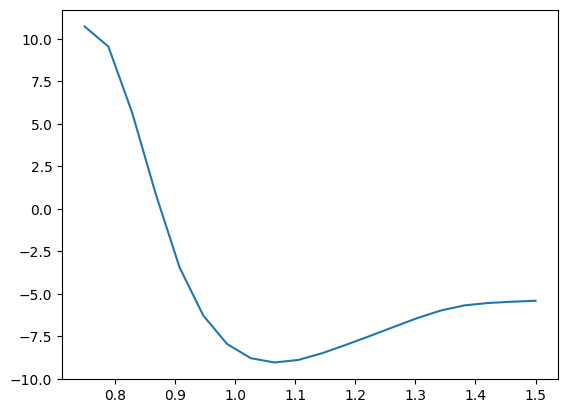

In [5]:
fig, ax = plt.subplots()
ax.plot(scales, energies)

# GPU Muller-Plathe trial, No GB

In [ ]:
# ------------------------------------------------------- #
# Settings
rNEMD_settings = {
  "nbins": 15,
  "n_cycles": 10,
  "steps_per_cycle": 1000,
  "taut": 0.1,
  "temperature_K": 650,
  "taup": 0.1,
  "timestep": 3
}
nbins = rNEMD_settings.pop('nbins')
temperature_K = rNEMD_settings.pop('temperature_K')
n_cycles = rNEMD_settings.pop('n_cycles')
steps_per_cycle = rNEMD_settings.pop('steps_per_cycle')
timestep = rNEMD_settings.pop('timestep')
taut = rNEMD_settings.pop('taut')

run_dir = 'rNEMD_test'

# ------------------------------------------------------- #
# Structure

# instantiate calculator
# calc = GPUNEP('Si_GAP_nep.txt', 
#               command='/home/dawson-smith/Desktop/Research/OtherSoftware/GPUMD/src/gpumd',
#               gpu_identifier_index=0,
#               directory=run_dir) # replace path on quest
calc = CPUNEP('Si_GAP_nep.txt')

# Read relaxed atomic positions, attach calculator
atoms = read('relax.traj').repeat([20,5,5])
calc.set_atoms(atoms)
atoms.calc = calc

print(len(atoms))

4000


## Equilibrate structure at 300 K in NPT ensemble

/home/dawson-smith/Non-Snap_Programs/anaconda3/envs/atomistic/lib/python3.12/site-packages/calorine/calculators/gpunep.py:243: UserWarning: rNEMD_test is not empty.
  warnings.warn(f'{self._directory} is not empty.')


<Axes: >

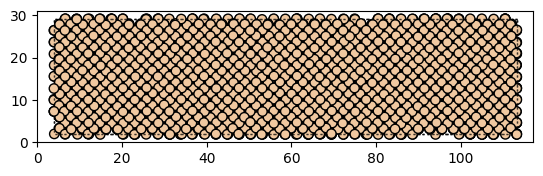

In [ ]:
import time
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
from ase.io.gpumd import read_gpumd

temp_1 = 10
temp_2 = 300

md_params = [
('dump_exyz', [1000, 1]), # [write out positions every 100 steps, write out velocities too]
 ('time_step', 1),
 ('ensemble', ['npt_scr', temp_1, temp_2, 200, 0, 100, 1000]), # [start_temp, end_temp, tau_t (coupling constant), pressure, bulk modulus, tau_p (coupling constant)]
# ('ensemble', ['nvt_nhc', temp_1, temp_2, 100]),
 ('run', 200000)] # run for n steps, 4000 atoms for 200,000 steps ~ 5 mins on home GPU
atoms = calc.run_custom_md(md_params, return_last_atoms=True)

fig, ax = plt.subplots()
plot_atoms(atoms, ax)

<>:6: SyntaxWarning: invalid escape sequence '\A'
<>:6: SyntaxWarning: invalid escape sequence '\A'
/tmp/ipykernel_8692/600057084.py:6: SyntaxWarning: invalid escape sequence '\A'
  ax.set_xlabel('Radial Distance [$\AA$]')


Text(0, 0.5, 'RDF')

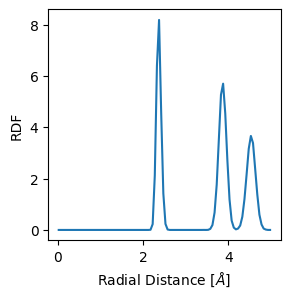

In [8]:
from ase.geometry.rdf import get_rdf
rdf = get_rdf(atoms=atoms, rmax=5, nbins=100)

fig, ax = plt.subplots(figsize = (3,3))
ax.plot(rdf[1], rdf[0])
ax.set_xlabel('Radial Distance [$\AA$]')
ax.set_ylabel('RDF')

In [3]:
def swap_velocities(atoms, cold_bin_indices, hot_bin_indices):
    """
    Swaps velocities of hottest atom in cold region and coldest atom in hot region.
    """
    # -------------------------------------------------------------- #
    # get coldest and hottest indices from each bin
    hottest_ind = cold_bin_indices[np.argmax(np.linalg.norm(atoms[cold_bin_indices].get_velocities(), axis = 1))] # Hottest atom in cold bin
    coldest_ind = hot_bin_indices[np.argmin(np.linalg.norm(atoms[hot_bin_indices].get_velocities(), axis = 1))] # coldest atom in hot bin

    # swap momenta (later, velocities)
    assert atoms[coldest_ind].symbol == atoms[hottest_ind].symbol
    cold_vel = atoms[coldest_ind].momentum.copy()
    hot_vel = atoms[hottest_ind].momentum.copy()

    atoms[coldest_ind].momentum = hot_vel
    atoms[hottest_ind].momentum = cold_vel

    # return velocities (hot, cold)
    return np.linalg.norm(hot_vel / atoms[hottest_ind].mass), np.linalg.norm(cold_vel/ atoms[coldest_ind].mass)


def bin_atoms(bins, scaled_x_positions):
    """
    Returns a list of lists containing atom indices per bin.
    [bin_1[atom indices in bin], bin_2[atom indices in bin 2]...]

    Args:
    bins (np.array): scaled x positions designating each bin.
    scaled_x_positions (np.array): scaled x positions for every atom in the simulation box 
    """
    
    # -------------------------------- #
    # assign atoms to bins
    atom_bin_assignments = np.digitize(scaled_x_positions, bins) # places atoms in bins based on index - len(atoms), 1 = first bin, 2 = second...

    # Find a way to vectorize this
    bins_containing_atom_indices = np.empty(np.unique(atom_bin_assignments).size, dtype = 'object')
    for ind, search_val in enumerate(np.unique(atom_bin_assignments)):
        bins_containing_atom_indices[ind] = np.where(atom_bin_assignments == search_val)[0]

    return bins_containing_atom_indices

302.9202355896675


KeyboardInterrupt: 

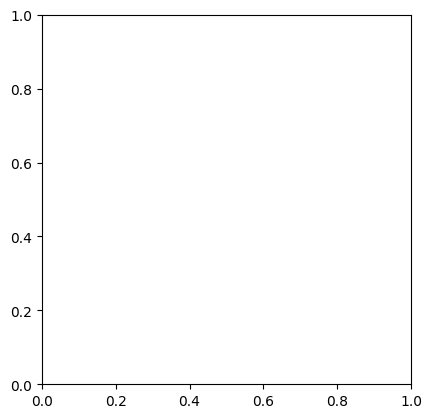

In [5]:
import time

#Standard Libraries
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

#ASE
from ase.io import read, write
from ase.visualize import view
from ase.visualize.plot import plot_atoms
from ase.filters import ExpCellFilter

    # MD
from ase import units

from ase.md.bussi import Bussi
from ase.optimize import BFGS
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution

#
import glob
import os
import sys
import json
import shutil as sh

import warnings
warnings.filterwarnings("ignore") # critical

# ----------------------------------------------------------------------------- #
# Set MD Parameters
run_dir = 'rNEMD'
temperature_K = 300
steps_per_cycle = 400 # controls energy flux
timestep = .4
n_cycles = 50 # n_cycles * steps_per_cycle = total steps
nbins = 15 # needs to be an odd number for now

md_params = [
('dump_position', steps_per_cycle),
('dump_velocity', steps_per_cycle),
('dump_exyz', [steps_per_cycle, 1]), # [write out positions every 100 steps, write out velocities too]
 ('time_step', timestep),
# ('ensemble', ['npt_scr', temperature_K, temperature_K, 10, 0, 100, 1000]), # [start_temp, end_temp, tau_t (coupling constant), pressure, bulk modulus, tau_p (coupling constant)]
('ensemble', ['npt_scr', temperature_K, temperature_K, 20, 0, 100, 200]), # [start_temp, end_temp, tau_t (coupling constant), pressure, bulk modulus, tau_p (coupling constant)]
# ('ensemble', ['nvt_nhc', temperature_K, temperature_K, 100]),
# ('ensemble', 'nve'),
 ('run', steps_per_cycle)] # run for n steps, 4000 atoms for 200,000 steps ~ 5 mins on home GPU

# ----------------------------------------------------------------------------- #
# Set Structure, initial velocities
atoms = read('equilibrated.traj')
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature_K)
print(atoms.get_temperature())

# -------------------------------------------------------------------------------------------- #
# Set atoms in bins
bins = np.linspace(0,1,nbins + 1) # nbins + 1 = n_divisions
scaled_x_positions = [atom.scaled_position[0] for atom in atoms] # compiles x coordinates of all atoms

binned_atom_indices = bin_atoms(bins, scaled_x_positions)

# Define which one is the cold bin and which one is the hot bin, assuming periodic boundaries. 
# NEED AN EVEN NUMBER OF BINS FOR NOW.
cold_bin = nbins // 4 + 1 
hot_bin = 3 * nbins // 4 + 1

# Visualize Bins
fig, ax = plt.subplots()
colorlist = np.empty(len(atoms), dtype='object')
for bin_ind, atom_indices in enumerate(binned_atom_indices):
    if bin_ind == hot_bin:
        colorlist[atom_indices] = 'red'
    elif bin_ind == cold_bin:
        colorlist[atom_indices] = 'blue'
    else:
        colorlist[atom_indices] = 'grey'

plot_atoms(atoms, ax, colors=colorlist)
plt.savefig('rNEMD_Setup.png', format='png')

# -------------------------------------------------------------------------------------------- #
# reverse Non-Equilibrium Molecular Dynamics a la Florian Muller-Plathe:

# set outputs to average
temps_times = np.zeros((n_cycles, nbins)) # output temps at each time step to gauge temp convergence
velocities_hot_cold = np.zeros((n_cycles,2)) # output velocities for calculating TC later

# Run simulation in cycles
for ind, cycle in enumerate(range(n_cycles)):
    # -------------------------------------- #
    print(ind)

    # Set calculator - have to redefine it everytime because calorine is weird
    calc = GPUNEP('Si_GAP_nep.txt', 
              command='/home/dawson-smith/Desktop/Research/OtherSoftware/GPUMD/src/gpumd',
              gpu_identifier_index=0,
              directory=run_dir,
              atoms = atoms) # replace path on quest

    # run simulation for steps_per_cycle
    atoms = calc.run_custom_md(md_params, return_last_atoms=True)

    # weird quirk of calorine, does not return atomic velocities, so have to assign them from an output file
    vels = pd.read_csv(run_dir + '/velocity.out', sep = ' ', header = None).iloc[-len(atoms):, :]
    atoms.set_velocities(vels / 0.098) # another quirk, velocity units are mismatched between the two packages (see ase.units module)
    print(atoms.get_temperature()) # sanity check
    
    # -------------------------------------- #
    # Swap velocities every cycle (every n steps_per_cycle)
    hot_atom_vel, cold_atom_vel = swap_velocities(atoms, binned_atom_indices[cold_bin], binned_atom_indices[hot_bin]) # swaps velocities of a hot and cold atom in specified slabs; also returns those velocities for later processing.
    # Record swapped velocities for energy flux calculation later:
    velocities_hot_cold[ind,:] = [hot_atom_vel, cold_atom_vel]

    # record temps for averaging later
    temps = np.zeros(nbins)
    for bin_ind, atom_indices in enumerate(binned_atom_indices):
        temps[bin_ind] = atoms[atom_indices].get_temperature()
    temps_times[ind,:] = temps
    
    # save outputs each step so you can look at them
    np.save('temps_times.npy', temps_times)
    np.save('velocities_hot_cold.npy', velocities_hot_cold)


Text(0, 0.5, 'RDF')

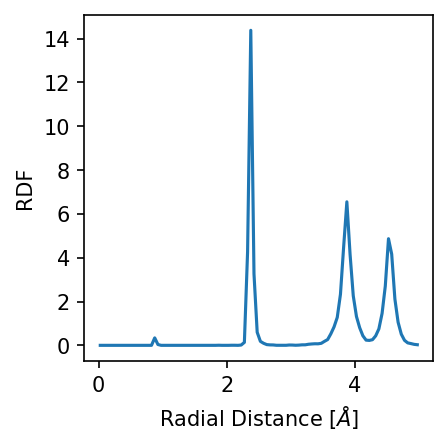

In [38]:
from ase.geometry.rdf import get_rdf
rdf = get_rdf(atoms=atoms, rmax=5, nbins=100)

fig, ax = plt.subplots(figsize = (3,3))
ax.plot(rdf[1], rdf[0])
ax.set_xlabel('Radial Distance [$\AA$]')
ax.set_ylabel('RDF')

(50, 15)
(15,)
[  1.55410497 373.82518674]


<Axes: >

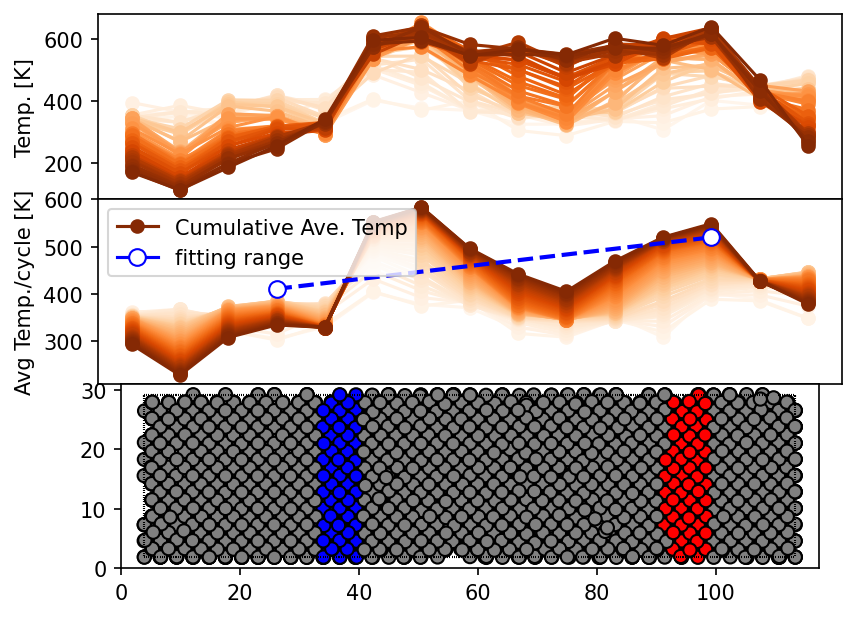

In [39]:
plt.rcParams['figure.dpi'] = 150
from matplotlib import cm
from matplotlib.colors import Normalize

# ----------------------------------------------------------------- #
# Load in data from quest run:
# traj = Trajectory(filename='rNEMD.traj', mode='r')

data = pd.read_csv('rNEMD.log', sep='\s+')
data.columns = ['Time[ps]', 'Etot/N[eV]', 'Epot/N[eV]', 'Ekin/N[eV]', 'T[K]', 'StressXX[GPa]','StressYY[GPa]','StressZZ[GPa]','StressXY[GPa]','StressXZ[GPa]','StressYZ[GPa]']

temps_times = np.load('temps_times.npy', allow_pickle=True)
temps_times = np.array(list(temps_times[:]), dtype=float)

temps_times = temps_times[~np.all(temps_times == 0, axis=1)]

velocities_hot_cold = np.load('velocities_hot_cold.npy')
velocities_hot_cold = velocities_hot_cold[~np.all(velocities_hot_cold == 0, axis=1)]

bins_containing_atom_indices = np.load('bin_atom_indices.npy', allow_pickle = True)

nbins = bins_containing_atom_indices.shape[0]
bins = np.linspace(0,1,nbins) # nbins + 1 = n_divisions
cold_bin = nbins // 4 + 1
hot_bin = 3 * nbins // 4 + 1

bin_dims = bins * atoms.cell[0,0]

# ----------------------------------------------------------------- #
# Do some math; fit profile here
cumulative_averages = np.cumsum(temps_times, axis=0) / (np.tile(np.atleast_2d(np.arange(temps_times.shape[0])).T, temps_times.shape[1]) + 1)# calculates running average for each time step

print(cumulative_averages.shape)
print(bin_dims.shape)

cutoff = 3
fit_params = np.polyfit(bin_dims[cutoff:-cutoff], cumulative_averages[-1,cutoff:-cutoff], 1)
print(fit_params)
x = np.linspace(bin_dims[cutoff], bin_dims[-cutoff], 10)

# ------------------------------------------------------------------ #
# Setup Plots
cmap = cm.Oranges
norm = Normalize(vmin=0, vmax = len(temps_times))

    # ------------------------------------ #
    # Plot temps_times
fig, axes = plt.subplots(3,1)
plt.subplots_adjust(hspace=0)
for ind, cycle in enumerate(temps_times):
    axes[0].plot(bin_dims, cycle, marker = 'o', color = cmap(norm(ind)), label = 'cycle' + str(ind))

axes[0].set_xlabel('Bin')
axes[0].set_ylabel('Temp. [K]')

    # ------------------------------------ #
    # Plot cumulative averages
for ind, cycle in enumerate(cumulative_averages):
    axes[1].plot(bin_dims, cycle, marker = 'o', color = cmap(norm(ind)), label = ['Cumulative Ave. Temp' if ind == len(cumulative_averages)-1 else None])

axes[1].plot(x, fit_params[0] * x + fit_params[1], color = 'blue', linestyle = 'dashed', linewidth = 2)
axes[1].plot(x[0], fit_params[0] * x[0] + fit_params[1], marker = 'o', color = 'blue', markerfacecolor = 'white', markersize = '8', label = 'fitting range')
axes[1].plot(x[-1], fit_params[0] * x[-1] + fit_params[1], marker = 'o', color = 'blue', markerfacecolor = 'white', markersize = '8')

axes[1].set_xlabel('Bin')
axes[1].set_ylabel('Avg Temp./cycle [K]')
axes[1].legend()

    # ------------------------------------ #
    # Plot Atoms
colorlist
colorlist = np.empty(len(atoms), dtype='object')
for bin_ind, atom_indices in enumerate(bins_containing_atom_indices):
    if bin_ind == hot_bin:
        colorlist[atom_indices] = 'red'
    elif bin_ind == cold_bin:
        colorlist[atom_indices] = 'blue'
    else:
        colorlist[atom_indices] = 'grey'
axes[2].set_aspect(axes[1].get_aspect())
plot_atoms(atoms, axes[2], colors = colorlist)